In [17]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Iterable, Any
from dataclasses import dataclass
import re
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import json
# Add project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project root: {project_root}")
print("Libraries imported successfully.")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Libraries imported successfully.


In [18]:
DATA_PATH = project_root / 'data' / 'raw' / 'IEEE_PHM' / 'dataset/'

In [4]:
@dataclass
class PHM2012Config:
    root_dir: str
    seq_len: int = 64
    stride: int = 1
    batch_size: int = 64
    num_workers: int = 0
    pin_memory: bool = False

    vibration_fs: float = 25600.0
    vibration_record_interval_sec: float = 10.0

    add_fft_features: bool = True
    fft_bands_hz: Tuple[Tuple[float, float], ...] = (
        (0, 500), (500, 1000), (1000, 2500),
        (2500, 5000), (5000, 10000), (10000, 12800),
    )

    target_col: str = "rul_sec"
    rul_cap_sec: Optional[float] = None
    target_transform: str = "log1p_standard"  # none | standard | log1p_standard

    include_full_test_labelled: bool = True  # include Full_Test_Set in supervised pool
    split_mode: str = "provided_lists"       # provided_lists | by_source_default

    train_bearings: Optional[List[str]] = None
    val_bearings: Optional[List[str]] = None
    test_bearings: Optional[List[str]] = None

    fill_temp_with_ffill_bfill: bool = True
    pad_mode: str = "edge"  # edge | zeros
    min_history: int = 1



In [7]:
_ACC_RE = re.compile(r"acc_(\d+)\.csv$", re.IGNORECASE)
_TEMP_RE = re.compile(r"temp_(\d+)\.csv$", re.IGNORECASE)

In [8]:
def _safe_read_csv(path: Path) -> pd.DataFrame:
    # Robust to comma/semicolon/whitespace variants.
    return pd.read_csv(path, header=None, engine="python", sep=None)

def _seconds_from_hmsu(df: pd.DataFrame, h: int, m: int, s: int, us: int) -> np.ndarray:
    hh = pd.to_numeric(df.iloc[:, h], errors="coerce").to_numpy(dtype=float)
    mm = pd.to_numeric(df.iloc[:, m], errors="coerce").to_numpy(dtype=float)
    ss = pd.to_numeric(df.iloc[:, s], errors="coerce").to_numpy(dtype=float)
    uu = pd.to_numeric(df.iloc[:, us], errors="coerce").to_numpy(dtype=float)
    return hh * 3600.0 + mm * 60.0 + ss + uu * 1e-6

def _basic_stats(x: np.ndarray, prefix: str) -> Dict[str, float]:
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        keys = ["mean","std","min","max","rms","p2p","abs_mean","skew","kurtosis","crest"]
        return {f"{prefix}_{k}": np.nan for k in keys}

    mean = float(np.mean(x))
    std = float(np.std(x))
    xmin = float(np.min(x))
    xmax = float(np.max(x))
    rms = float(np.sqrt(np.mean(np.square(x))))
    p2p = float(xmax - xmin)
    abs_mean = float(np.mean(np.abs(x)))

    if std < 1e-12:
        skew, kurt = 0.0, 0.0
    else:
        z = (x - mean) / std
        skew = float(np.mean(z ** 3))
        kurt = float(np.mean(z ** 4) - 3.0)

    crest = float(np.max(np.abs(x)) / (rms + 1e-12))
    return {
        f"{prefix}_mean": mean,
        f"{prefix}_std": std,
        f"{prefix}_min": xmin,
        f"{prefix}_max": xmax,
        f"{prefix}_rms": rms,
        f"{prefix}_p2p": p2p,
        f"{prefix}_abs_mean": abs_mean,
        f"{prefix}_skew": skew,
        f"{prefix}_kurtosis": kurt,
        f"{prefix}_crest": crest,
    }

def _fft_band_energies(x: np.ndarray, fs: float, bands: Iterable[Tuple[float, float]], prefix: str) -> Dict[str, float]:
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        out = {}
        for lo, hi in bands:
            out[f"{prefix}_band_{int(lo)}_{int(hi)}_energy"] = np.nan
            out[f"{prefix}_band_{int(lo)}_{int(hi)}_rel_energy"] = np.nan
        out[f"{prefix}_spec_total_energy"] = np.nan
        out[f"{prefix}_dom_freq_hz"] = np.nan
        out[f"{prefix}_dom_power"] = np.nan
        return out

    x = x - np.mean(x)
    spec = np.fft.rfft(x)
    psd = (np.abs(spec) ** 2) / max(len(x), 1)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = float(np.sum(psd) + 1e-12)

    out = {}
    for lo, hi in bands:
        mask = (freqs >= lo) & (freqs < hi)
        e = float(np.sum(psd[mask]))
        out[f"{prefix}_band_{int(lo)}_{int(hi)}_energy"] = e
        out[f"{prefix}_band_{int(lo)}_{int(hi)}_rel_energy"] = e / total

    out[f"{prefix}_spec_total_energy"] = total
    if len(psd) > 1:
        idx = int(np.argmax(psd[1:]) + 1)
        out[f"{prefix}_dom_freq_hz"] = float(freqs[idx])
        out[f"{prefix}_dom_power"] = float(psd[idx])
    else:
        out[f"{prefix}_dom_freq_hz"] = 0.0
        out[f"{prefix}_dom_power"] = 0.0
    return out

def _extract_vibration_features(acc_file: Path, cfg: PHM2012Config) -> Dict[str, Any]:
    # Expected columns per challenge PDF:
    # [Hour, Minute, Second, Micro-second, Horiz_accel, Vert_accel]
    df = _safe_read_csv(acc_file)
    if df.shape[1] < 6:
        raise ValueError(f"Unexpected acc format {df.shape[1]} cols: {acc_file}")

    tsec = _seconds_from_hmsu(df, 0, 1, 2, 3)
    h = pd.to_numeric(df.iloc[:, 4], errors="coerce").to_numpy(dtype=float)
    v = pd.to_numeric(df.iloc[:, 5], errors="coerce").to_numpy(dtype=float)

    feat = {}
    feat.update(_basic_stats(h, "h"))
    feat.update(_basic_stats(v, "v"))

    if np.nanstd(h) > 0 and np.nanstd(v) > 0:
        feat["hv_corr"] = float(np.corrcoef(h, v)[0, 1])
    else:
        feat["hv_corr"] = 0.0
    feat["hv_rms_ratio"] = feat["h_rms"] / (feat["v_rms"] + 1e-12)

    if cfg.add_fft_features:
        feat.update(_fft_band_energies(h, cfg.vibration_fs, cfg.fft_bands_hz, "h"))
        feat.update(_fft_band_energies(v, cfg.vibration_fs, cfg.fft_bands_hz, "v"))

    m = _ACC_RE.search(acc_file.name)
    feat["record_idx"] = int(m.group(1)) if m else -1
    feat["record_time_from_file_s"] = float(np.nanmin(tsec)) if len(tsec) else np.nan
    feat["n_samples_acc"] = int(len(df))
    return feat

def _extract_temperature_summary(temp_file: Path) -> Dict[str, Any]:
    # Expected columns per challenge PDF:
    # [Hour, Minute, Second, 0.x second, RTD sensor]
    df = _safe_read_csv(temp_file)
    if df.shape[1] < 5:
        raise ValueError(f"Unexpected temp format {df.shape[1]} cols: {temp_file}")

    tsec = _seconds_from_hmsu(df, 0, 1, 2, 3)
    temp = pd.to_numeric(df.iloc[:, 4], errors="coerce").to_numpy(dtype=float)

    m = _TEMP_RE.search(temp_file.name)
    rec_idx = int(m.group(1)) if m else -1

    return {
        "temp_record_idx": rec_idx,
        "temp_time_from_file_s": float(np.nanmin(tsec)) if len(tsec) else np.nan,
        "temp_n_samples": int(len(df)),
        "temp_mean": float(np.nanmean(temp)) if len(temp) else np.nan,
        "temp_std": float(np.nanstd(temp)) if len(temp) else np.nan,
        "temp_min": float(np.nanmin(temp)) if len(temp) else np.nan,
        "temp_max": float(np.nanmax(temp)) if len(temp) else np.nan,
        "temp_last": float(temp[-1]) if len(temp) else np.nan,
    }

def infer_condition_from_bearing_name(name: str) -> Optional[int]:
    m = re.match(r"Bearing(\d+)_\d+", name)
    return int(m.group(1)) if m else None

def _list_bearing_dirs(root: Path) -> List[Tuple[str, str, Path]]:
    out = []
    for source in ["Learning_set", "Full_Test_Set", "Test_set"]:
        src = root / source
        if not src.exists():
            continue
        for p in sorted([x for x in src.iterdir() if x.is_dir()]):
            out.append((source, p.name, p))
    return out

def process_bearing_folder(bearing_dir: Path, source: str, cfg: PHM2012Config) -> pd.DataFrame:
    acc_files = sorted(
        [p for p in bearing_dir.glob("acc_*.csv")],
        key=lambda p: int(_ACC_RE.search(p.name).group(1))
    )
    temp_files = sorted(
        [p for p in bearing_dir.glob("temp_*.csv")],
        key=lambda p: int(_TEMP_RE.search(p.name).group(1))
    )

    if len(acc_files) == 0:
        warnings.warn(f"No acc files in {bearing_dir}")
        return pd.DataFrame()

    acc_rows = []
    for f in acc_files:
        row = _extract_vibration_features(f, cfg)
        row["bearing_name"] = bearing_dir.name
        row["source"] = source
        acc_rows.append(row)
    acc_df = pd.DataFrame(acc_rows).sort_values("record_idx").reset_index(drop=True)

    acc_df["step_idx"] = np.arange(len(acc_df), dtype=int)
    acc_df["t_rel_sec"] = acc_df["step_idx"] * cfg.vibration_record_interval_sec
    acc_df["condition_id"] = infer_condition_from_bearing_name(bearing_dir.name)

    if len(temp_files) > 0:
        temp_rows = []
        for f in temp_files:
            row = _extract_temperature_summary(f)
            row["bearing_name"] = bearing_dir.name
            row["source"] = source
            temp_rows.append(row)
        temp_df = pd.DataFrame(temp_rows).sort_values("temp_record_idx").reset_index(drop=True)

        # Approximate minute schedule from file order (per challenge docs: 600 samples / minute)
        temp_df["temp_step_idx"] = np.arange(len(temp_df), dtype=int)
        temp_df["temp_t_rel_sec"] = temp_df["temp_step_idx"] * 60.0

        acc_df = pd.merge_asof(
            acc_df.sort_values("t_rel_sec"),
            temp_df.sort_values("temp_t_rel_sec"),
            left_on="t_rel_sec",
            right_on="temp_t_rel_sec",
            by=["bearing_name", "source"],
            direction="backward",
            allow_exact_matches=True,
        )
        acc_df["temp_available"] = (~acc_df["temp_mean"].isna()).astype(int)

        if cfg.fill_temp_with_ffill_bfill:
            temp_cols = [c for c in acc_df.columns if c.startswith("temp_")]
            acc_df[temp_cols] = acc_df.groupby("bearing_name")[temp_cols].transform(lambda s: s.ffill().bfill())

    else:
        for c in ["temp_record_idx","temp_time_from_file_s","temp_n_samples","temp_mean","temp_std","temp_min","temp_max","temp_last","temp_step_idx","temp_t_rel_sec"]:
            acc_df[c] = np.nan
        acc_df["temp_available"] = 0

    # Labels:
    # - Learning_set / Full_Test_Set: run-to-failure available => RUL can be computed from end
    # - Test_set: challenge-truncated => keep NaN labels
    if source in {"Learning_set", "Full_Test_Set"}:
        max_t = float(acc_df["t_rel_sec"].max())
        acc_df["rul_sec"] = max_t - acc_df["t_rel_sec"]
        acc_df["life_frac_elapsed"] = acc_df["t_rel_sec"] / (max_t if max_t > 0 else 1.0)
    else:
        acc_df["rul_sec"] = np.nan
        acc_df["life_frac_elapsed"] = np.nan

    return acc_df

def build_feature_table(cfg: PHM2012Config) -> Tuple[pd.DataFrame, pd.DataFrame]:
    root = Path(cfg.root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Dataset root not found: {root}")

    frames = []
    meta_rows = []

    for source, bearing_name, bdir in _list_bearing_dirs(root):
        if (source == "Full_Test_Set") and (not cfg.include_full_test_labelled):
            continue

        df = process_bearing_folder(bdir, source, cfg)
        if df.empty:
            continue
        frames.append(df)

        meta_rows.append({
            "bearing_name": bearing_name,
            "source": source,
            "condition_id": infer_condition_from_bearing_name(bearing_name),
            "n_acc_records": int(df.shape[0]),
            "duration_sec_from_acc": float(df["t_rel_sec"].max()) if df.shape[0] else 0.0,
            "has_temp_any": int(df["temp_available"].max()) if "temp_available" in df.columns else 0,
            "label_available": int(df["rul_sec"].notna().all()),
        })

    if not frames:
        raise RuntimeError("No bearing data parsed.")

    full_df = pd.concat(frames, ignore_index=True).sort_values(["source","bearing_name","step_idx"]).reset_index(drop=True)
    meta_df = pd.DataFrame(meta_rows).sort_values(["source","bearing_name"]).reset_index(drop=True)
    return full_df, meta_df

In [9]:
def eda_summary(full_df: pd.DataFrame, meta_df: pd.DataFrame) -> Dict[str, Any]:
    return {
        "n_rows": int(full_df.shape[0]),
        "n_columns": int(full_df.shape[1]),
        "n_bearings_total": int(meta_df["bearing_name"].nunique()),
        "n_bearings_by_source": meta_df.groupby("source")["bearing_name"].nunique().to_dict(),
        "rows_by_source": full_df.groupby("source").size().to_dict(),
        "temp_missing_rate_overall": float(full_df["temp_mean"].isna().mean()) if "temp_mean" in full_df.columns else None,
        "records_by_bearing": meta_df.set_index("bearing_name")["n_acc_records"].to_dict(),
        "duration_sec_by_bearing": meta_df.set_index("bearing_name")["duration_sec_from_acc"].to_dict(),
    }

def plot_eda(meta_df: pd.DataFrame, full_df: pd.DataFrame, out_dir: Optional[str] = None, max_bearings_trend: int = 6) -> None:
    out = Path(out_dir) if out_dir else None
    if out:
        out.mkdir(parents=True, exist_ok=True)

    tmp = meta_df.sort_values(["source","bearing_name"]).copy()

    # 1) recordings per bearing
    plt.figure(figsize=(12, 4))
    plt.bar(tmp["bearing_name"], tmp["n_acc_records"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("# acc recordings")
    plt.title("PHM2012: recordings per bearing")
    plt.tight_layout()
    if out: plt.savefig(out / "01_records_per_bearing.png", dpi=150)
    plt.show()

    # 2) duration per bearing
    plt.figure(figsize=(12, 4))
    plt.bar(tmp["bearing_name"], tmp["duration_sec_from_acc"] / 60.0)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Duration (min)")
    plt.title("PHM2012: duration per bearing (from acc file count × 10s)")
    plt.tight_layout()
    if out: plt.savefig(out / "02_duration_per_bearing.png", dpi=150)
    plt.show()

    # 3) feature trends (sample bearings)
    trend_cols = [c for c in ["h_rms","v_rms","h_kurtosis","v_kurtosis","temp_mean"] if c in full_df.columns]
    sample_bearings = list(tmp["bearing_name"].head(max_bearings_trend))
    for col in trend_cols:
        plt.figure(figsize=(10, 4))
        for b in sample_bearings:
            d = full_df[full_df["bearing_name"] == b]
            plt.plot(d["t_rel_sec"] / 60.0, d[col], label=b, alpha=0.9)
        plt.xlabel("Time (min)")
        plt.ylabel(col)
        plt.title(f"Trend: {col}")
        plt.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        if out: plt.savefig(out / f"trend_{col}.png", dpi=150)
        plt.show()

    # 4) target distribution (labelled only)
    if "rul_sec" in full_df.columns:
        y = full_df["rul_sec"].dropna().to_numpy()
        if y.size > 0:
            plt.figure(figsize=(7, 4))
            plt.hist(y / 60.0, bins=50)
            plt.xlabel("RUL (min)")
            plt.ylabel("Count")
            plt.title("Label distribution (all labelled timesteps)")
            plt.tight_layout()
            if out: plt.savefig(out / "03_rul_hist.png", dpi=150)
            plt.show()

    # 5) correlation heatmap (subset to avoid giant plots)
    numeric_cols = full_df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = {"record_idx","step_idx","t_rel_sec","rul_sec","life_frac_elapsed","condition_id","temp_record_idx","temp_step_idx","temp_t_rel_sec","record_time_from_file_s","temp_time_from_file_s"}
    feat_cols = [c for c in numeric_cols if c not in exclude]
    feat_cols = feat_cols[:40]
    if len(feat_cols) >= 2:
        corr = full_df[feat_cols].corr(numeric_only=True)
        plt.figure(figsize=(12, 9))
        im = plt.imshow(corr.values, aspect="auto")
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.xticks(range(len(feat_cols)), feat_cols, rotation=90, fontsize=7)
        plt.yticks(range(len(feat_cols)), feat_cols, fontsize=7)
        plt.title("Feature correlation heatmap (subset)")
        plt.tight_layout()
        if out: plt.savefig(out / "04_corr_heatmap.png", dpi=150)
        plt.show()

In [10]:
@dataclass
class FeatureNormalizer:
    feature_cols: List[str]
    mean_: Optional[np.ndarray] = None
    std_: Optional[np.ndarray] = None

    def fit(self, df: pd.DataFrame) -> "FeatureNormalizer":
        x = df[self.feature_cols].to_numpy(dtype=np.float64)
        self.mean_ = np.nanmean(x, axis=0)
        self.std_ = np.nanstd(x, axis=0)
        self.std_[self.std_ < 1e-12] = 1.0
        return self

    def transform_array(self, x: np.ndarray) -> np.ndarray:
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("FeatureNormalizer not fitted.")
        x = np.asarray(x, dtype=np.float64)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        return (x - self.mean_) / self.std_

@dataclass
class TargetNormalizer:
    mode: str = "log1p_standard"
    rul_cap_sec: Optional[float] = None
    mean_: float = 0.0
    std_: float = 1.0
    fitted_: bool = False

    def _pre(self, y: np.ndarray) -> np.ndarray:
        y = np.asarray(y, dtype=np.float64)
        if self.rul_cap_sec is not None:
            y = np.minimum(y, self.rul_cap_sec)

        if self.mode == "none":
            return y
        elif self.mode == "standard":
            return y
        elif self.mode == "log1p_standard":
            return np.log1p(np.clip(y, 0.0, None))
        else:
            raise ValueError(f"Unknown mode: {self.mode}")

    def fit(self, y: np.ndarray) -> "TargetNormalizer":
        yp = self._pre(y)
        if self.mode == "none":
            self.mean_, self.std_ = 0.0, 1.0
        else:
            self.mean_ = float(np.mean(yp))
            self.std_ = float(np.std(yp))
            if self.std_ < 1e-12:
                self.std_ = 1.0
        self.fitted_ = True
        return self

    def transform(self, y: np.ndarray) -> np.ndarray:
        if not self.fitted_:
            raise RuntimeError("TargetNormalizer not fitted.")
        yp = self._pre(y)
        if self.mode == "none":
            return yp
        return (yp - self.mean_) / self.std_

    def inverse_transform(self, z: np.ndarray) -> np.ndarray:
        if not self.fitted_:
            raise RuntimeError("TargetNormalizer not fitted.")
        z = np.asarray(z, dtype=np.float64)
        if self.mode == "none":
            y = z
        else:
            base = z * self.std_ + self.mean_
            if self.mode == "log1p_standard":
                y = np.expm1(base)
            else:
                y = base
        y = np.maximum(y, 0.0)
        if self.rul_cap_sec is not None:
            y = np.minimum(y, self.rul_cap_sec)
        return y

def denormalize_rul(pred: torch.Tensor | np.ndarray, target_normalizer: TargetNormalizer) -> np.ndarray:
    arr = pred.detach().cpu().numpy() if isinstance(pred, torch.Tensor) else np.asarray(pred)
    return target_normalizer.inverse_transform(arr)

In [11]:
def make_bearing_splits(meta_df: pd.DataFrame, cfg: PHM2012Config) -> Tuple[List[str], List[str], List[str]]:
    labelled = meta_df[meta_df["label_available"] == 1].copy()

    if cfg.split_mode == "provided_lists" and cfg.train_bearings and cfg.val_bearings and cfg.test_bearings:
        return cfg.train_bearings, cfg.val_bearings, cfg.test_bearings

    # Default: train on Learning_set, val/test on Full_Test_Set (if available)
    train = labelled[labelled["source"] == "Learning_set"]["bearing_name"].tolist()
    full_test = sorted(labelled[labelled["source"] == "Full_Test_Set"]["bearing_name"].tolist())

    if len(full_test) >= 4:
        k = max(2, len(full_test) // 3)
        val = full_test[:k]
        test = full_test[k:]
        return train, val, test

    # Fallback: split Learning_set itself (group split)
    train = sorted(train)
    if len(train) >= 4:
        val = train[-2:-1]
        test = train[-1:]
        train = [b for b in train if b not in set(val + test)]
    elif len(train) >= 2:
        val = train[-1:]
        test = []
        train = train[:-1]
    else:
        val, test = [], []
    return train, val, test

def default_feature_columns(full_df: pd.DataFrame) -> List[str]:
    numeric_cols = full_df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = {
        "record_idx","step_idx","t_rel_sec","rul_sec","life_frac_elapsed",
        "condition_id","temp_record_idx","temp_step_idx","temp_t_rel_sec",
        "record_time_from_file_s","temp_time_from_file_s"
    }
    return sorted([c for c in numeric_cols if c not in exclude])


In [12]:
class PHMSequenceDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        bearing_list: List[str],
        seq_len: int,
        stride: int,
        target_col: str,
        feature_normalizer: Optional[FeatureNormalizer],
        target_normalizer: Optional[TargetNormalizer],
        with_targets: bool = True,
        pad_mode: str = "edge",
        min_history: int = 1,
    ):
        self.df = df[df["bearing_name"].isin(bearing_list)].copy().sort_values(["bearing_name","step_idx"]).reset_index(drop=True)
        self.feature_cols = feature_cols
        self.seq_len = int(seq_len)
        self.stride = int(stride)
        self.target_col = target_col
        self.feature_normalizer = feature_normalizer
        self.target_normalizer = target_normalizer
        self.with_targets = with_targets
        self.pad_mode = pad_mode
        self.min_history = min_history

        self.groups: Dict[str, pd.DataFrame] = {}
        self.samples: List[Tuple[str, int]] = []  # (bearing_name, end_idx_in_group)

        for b in bearing_list:
            g = self.df[self.df["bearing_name"] == b].copy().reset_index(drop=True)
            if g.empty:
                continue
            self.groups[b] = g
            for end_idx in range(len(g)):
                if (end_idx % self.stride) != 0:
                    continue
                if (end_idx + 1) < self.min_history:
                    continue
                if self.with_targets and pd.isna(g.loc[end_idx, self.target_col]):
                    continue
                self.samples.append((b, end_idx))

        if len(self.samples) == 0:
            warnings.warn("No samples in PHMSequenceDataset. Check splits/preprocessing.")

    def __len__(self) -> int:
        return len(self.samples)

    def _pad_left(self, x: np.ndarray) -> np.ndarray:
        if x.shape[0] == self.seq_len:
            return x
        need = self.seq_len - x.shape[0]
        if need <= 0:
            return x[-self.seq_len:]
        if self.pad_mode == "zeros":
            pad = np.zeros((need, x.shape[1]), dtype=x.dtype)
        else:
            first = x[:1] if x.shape[0] > 0 else np.zeros((1, x.shape[1]), dtype=x.dtype)
            pad = np.repeat(first, need, axis=0)
        return np.concatenate([pad, x], axis=0)

    def __getitem__(self, idx: int):
        b, end_idx = self.samples[idx]
        g = self.groups[b]
        start_idx = max(0, end_idx - self.seq_len + 1)

        x = g.loc[start_idx:end_idx, self.feature_cols].to_numpy(dtype=np.float64)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        if self.feature_normalizer is not None:
            x = self.feature_normalizer.transform_array(x)
        x = self._pad_left(x).astype(np.float32)

        x_t = torch.from_numpy(x)
        meta = {
            "bearing_name": b,
            "end_step_idx": int(g.loc[end_idx, "step_idx"]),
            "t_rel_sec": float(g.loc[end_idx, "t_rel_sec"]),
            "condition_id": int(g.loc[end_idx, "condition_id"]) if not pd.isna(g.loc[end_idx, "condition_id"]) else -1,
        }

        if self.with_targets:
            y = np.array([float(g.loc[end_idx, self.target_col])], dtype=np.float64)
            if self.target_normalizer is not None:
                y = self.target_normalizer.transform(y)
            y_t = torch.tensor(y[0], dtype=torch.float32)
            return x_t, y_t, meta
        else:
            return x_t, meta

def make_dataloaders(full_df: pd.DataFrame, meta_df: pd.DataFrame, cfg: PHM2012Config, feature_cols: Optional[List[str]] = None) -> Dict[str, Any]:
    if feature_cols is None:
        feature_cols = default_feature_columns(full_df)

    train_bearings, val_bearings, test_bearings = make_bearing_splits(meta_df, cfg)

    train_rows = full_df[(full_df["bearing_name"].isin(train_bearings)) & (full_df[cfg.target_col].notna())].copy()
    if train_rows.empty:
        raise RuntimeError("No training rows found. Check split config.")

    feat_norm = FeatureNormalizer(feature_cols).fit(train_rows)
    tgt_norm = TargetNormalizer(mode=cfg.target_transform, rul_cap_sec=cfg.rul_cap_sec).fit(
        train_rows[cfg.target_col].to_numpy(dtype=np.float64)
    )

    train_ds = PHMSequenceDataset(
        full_df, feature_cols, train_bearings, cfg.seq_len, cfg.stride, cfg.target_col,
        feat_norm, tgt_norm, with_targets=True, pad_mode=cfg.pad_mode, min_history=cfg.min_history
    )
    val_ds = PHMSequenceDataset(
        full_df, feature_cols, val_bearings, cfg.seq_len, cfg.stride, cfg.target_col,
        feat_norm, tgt_norm, with_targets=True, pad_mode=cfg.pad_mode, min_history=cfg.min_history
    ) if len(val_bearings) else None
    test_ds = PHMSequenceDataset(
        full_df, feature_cols, test_bearings, cfg.seq_len, cfg.stride, cfg.target_col,
        feat_norm, tgt_norm, with_targets=True, pad_mode=cfg.pad_mode, min_history=cfg.min_history
    ) if len(test_bearings) else None

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=cfg.pin_memory) if val_ds else None
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=cfg.pin_memory) if test_ds else None

    return {
        "feature_cols": feature_cols,
        "train_bearings": train_bearings,
        "val_bearings": val_bearings,
        "test_bearings": test_bearings,
        "feature_normalizer": feat_norm,
        "target_normalizer": tgt_norm,
        "train_dataset": train_ds,
        "val_dataset": val_ds,
        "test_dataset": test_ds,
        "train_dataloader": train_loader,
        "val_dataloader": val_loader,
        "test_dataloader": test_loader,
    }

In [13]:
def make_inference_loader_for_truncated_test(full_df: pd.DataFrame, cfg: PHM2012Config, feature_cols: List[str], feature_normalizer: FeatureNormalizer):
    test_bearings = sorted(full_df.loc[full_df["source"] == "Test_set", "bearing_name"].unique().tolist())
    ds = PHMSequenceDataset(
        full_df, feature_cols, test_bearings, cfg.seq_len, cfg.stride, cfg.target_col,
        feature_normalizer, None, with_targets=False, pad_mode=cfg.pad_mode, min_history=cfg.min_history
    )
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)


In [ ]:
root = DATA_PATH

cfg = PHM2012Config(
        root_dir=root,
        seq_len=64,
        stride=1,
        batch_size=64,
        add_fft_features=True,
        rul_cap_sec=None,  # e.g., 3600 for capped RUL
        target_transform="log1p_standard",
    )

    


=== Per-bearing metadata ===
bearing_name        source  condition_id  n_acc_records  duration_sec_from_acc  has_temp_any  label_available
  Bearing1_3 Full_Test_Set             1           2375                23740.0             0                1
  Bearing1_4 Full_Test_Set             1           1428                14270.0             1                1
  Bearing1_5 Full_Test_Set             1           2463                24620.0             1                1
  Bearing1_6 Full_Test_Set             1           2448                24470.0             1                1
  Bearing1_7 Full_Test_Set             1           2259                22580.0             1                1
  Bearing2_3 Full_Test_Set             2           1955                19540.0             0                1
  Bearing2_4 Full_Test_Set             2            751                 7500.0             1                1
  Bearing2_5 Full_Test_Set             2           2311                23100.0            

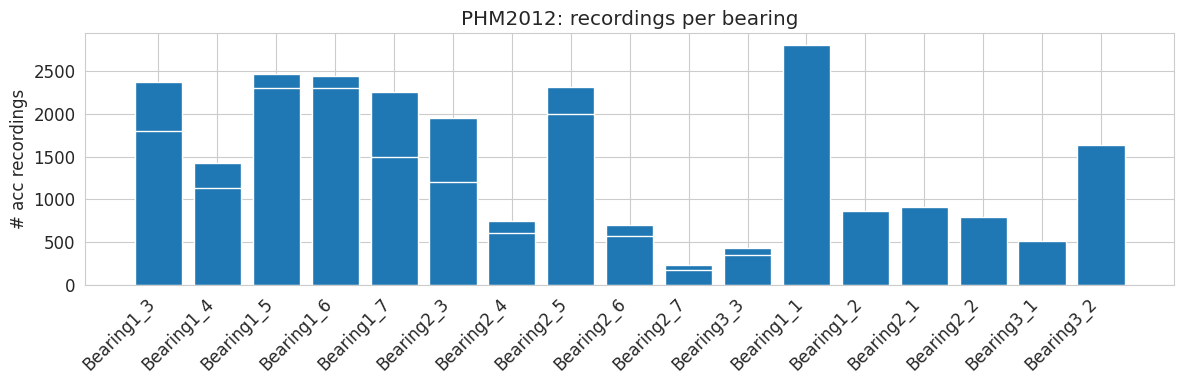

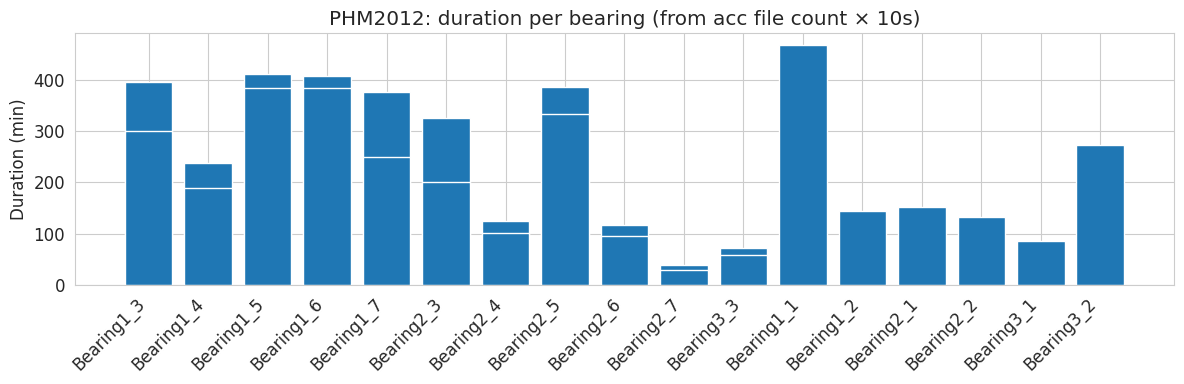

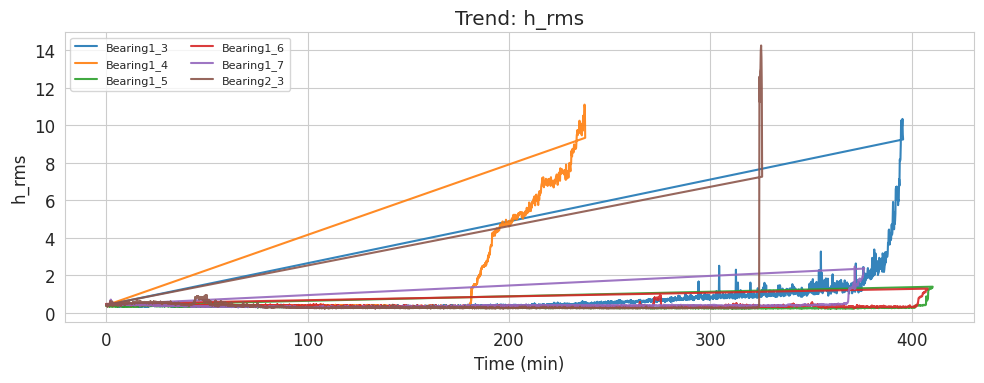

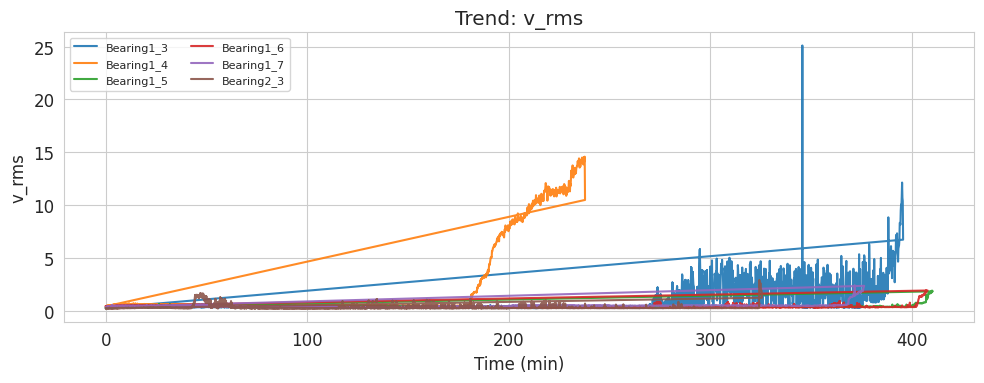

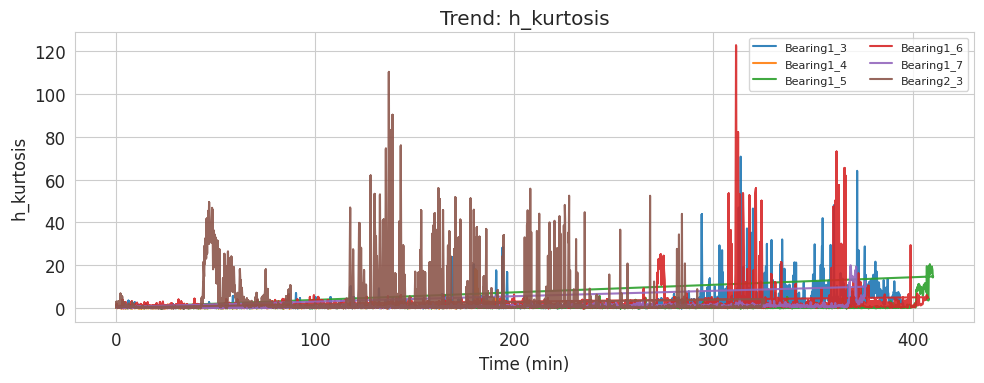

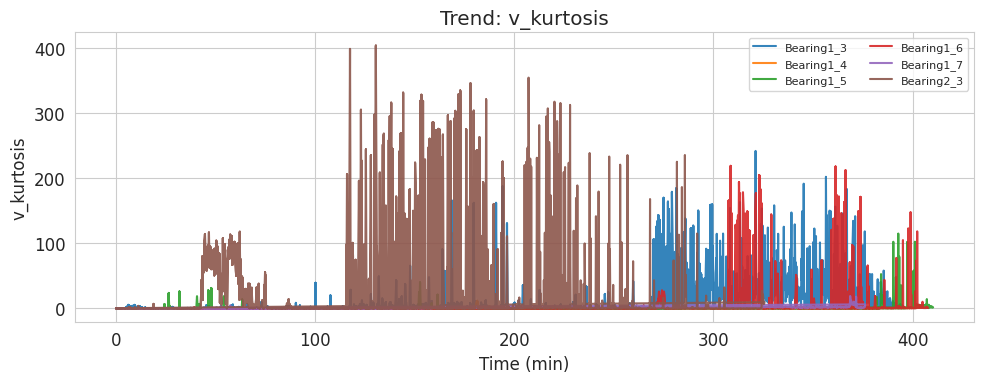

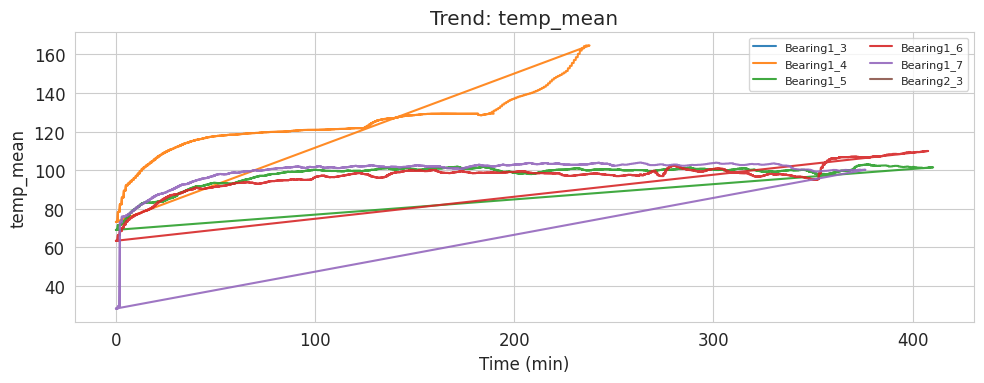

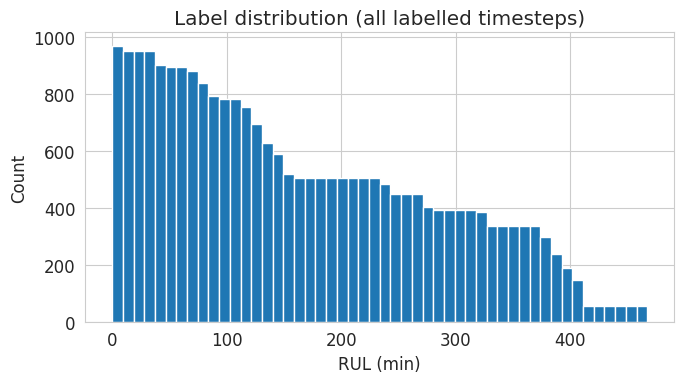

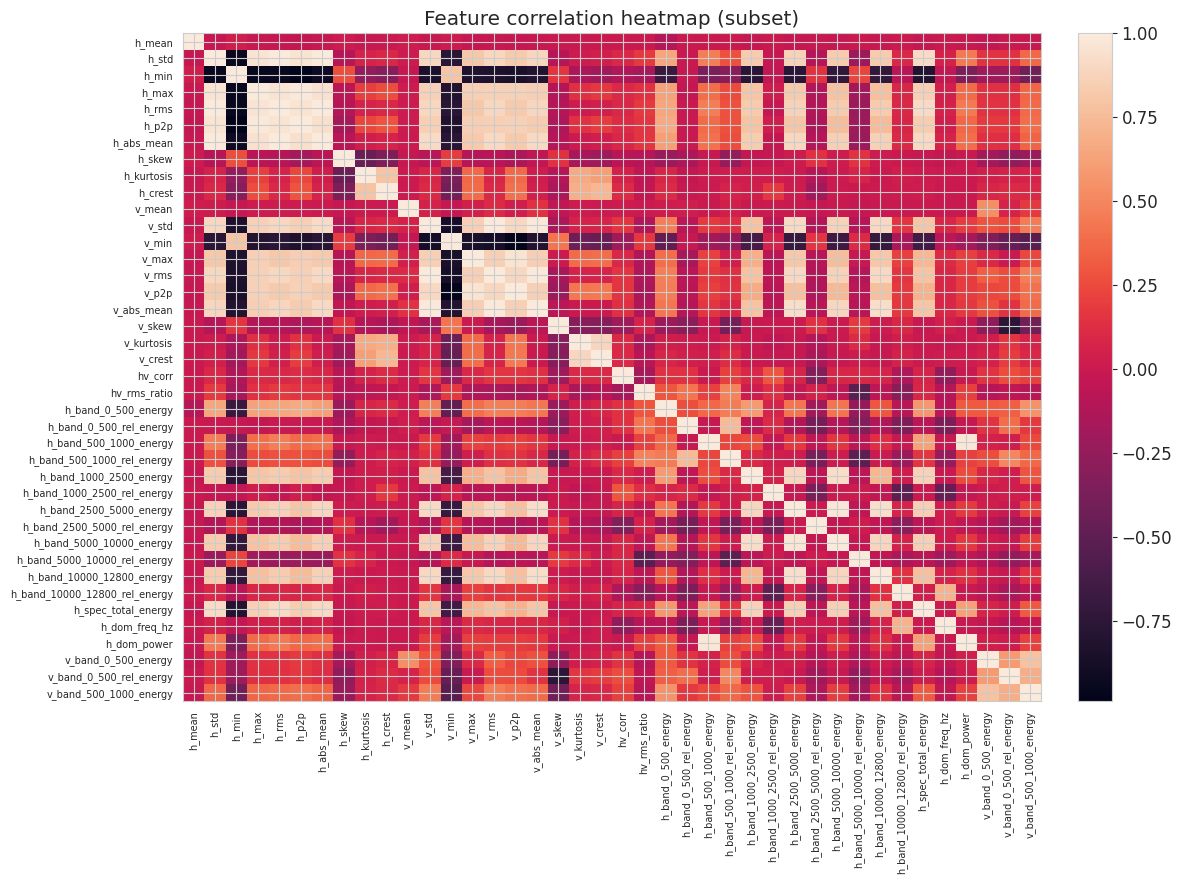


Splits:
train: ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']
val  : ['Bearing1_3', 'Bearing1_4', 'Bearing1_5']
test : ['Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']
n_features: 60

Batch shapes:
X: torch.Size([64, 64, 60])
y: torch.Size([64])
First 5 y (normalized): [ 0.2667289  -0.32983294  0.24330209  1.0241733   1.139325  ]
First 5 y (denorm sec): [ 7419.99994441  3700.00001243  7219.99998953 17950.00009509
 20529.99874526]
Inference X shape: torch.Size([64, 64, 60])


In [19]:
full_df, meta_df = build_feature_table(cfg)

print("\n=== Per-bearing metadata ===")
print(meta_df.to_string(index=False))
print("\n=== EDA summary ===")
print(json.dumps(eda_summary(full_df, meta_df), indent=2))

plot_eda(meta_df, full_df, out_dir="./eda_plots")

bundle = make_dataloaders(full_df, meta_df, cfg)
train_loader = bundle["train_dataloader"]
val_loader = bundle["val_dataloader"]
test_loader = bundle["test_dataloader"]

print("\nSplits:")
print("train:", bundle["train_bearings"])
print("val  :", bundle["val_bearings"])
print("test :", bundle["test_bearings"])
print("n_features:", len(bundle["feature_cols"]))

xb, yb, mb = next(iter(train_loader))
print("\nBatch shapes:")
print("X:", xb.shape)   # (batch, seq, features)
print("y:", yb.shape)   # (batch,)

y_denorm = denormalize_rul(yb, bundle["target_normalizer"])
print("First 5 y (normalized):", yb[:5].numpy())
print("First 5 y (denorm sec):", y_denorm[:5])

# Optional challenge-style truncated test inference loader:
if (Path(root) / "Test_set").exists():
    inf_loader = make_inference_loader_for_truncated_test(
        full_df, cfg, bundle["feature_cols"], bundle["feature_normalizer"]
    )
    batch = next(iter(inf_loader))
    x_inf, meta_inf = batch
    print("Inference X shape:", x_inf.shape)